# Import Dataset from Kaggle

In [ ]:
import kagglehub

# Download latest version of Carla Object Detection Dataset
object_detection_data_path = kagglehub.dataset_download("ibrahimalobaid/object-detection-carla-self-driving-car")
print("Path to Carla Object Detection Dataset files:", object_detection_data_path)

Using Colab cache for faster access to the 'object-detection-carla-self-driving-car' dataset.
Path to Carla Object Detection Dataset files: /kaggle/input/object-detection-carla-self-driving-car


In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Imports and Initialize to T4 Runtime

In [ ]:
import os
from pathlib import Path
import time
import shutil

# Deep Learning Imports
import numpy as np
import pandas as pd
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import functional as TF
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader, Dataset, random_split
import matplotlib.pyplot as plt

from PIL import Image

# Allow for T4 GPU compatibility
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(torch.cuda.get_device_name(0))

cuda
Tesla T4


# Data Loader

In [ ]:
import random
from torch.utils.data import WeightedRandomSampler

DATASET_CLASS_NAMES = (
    "bike", "motobike", "person", "traffic_light_green",
    "traffic_light_orange", "traffic_light_red", "traffic_sign_30",
    "traffic_sign_60", "traffic_sign_90", "vehicle",
)

CLASS_NAMES = (
    "traffic_light_green",
    "traffic_light_orange",
    "traffic_light_red",
    "traffic_sign_30",
    "traffic_sign_60",
    "traffic_sign_90",
)

ORIGINAL_CLASS_ID_TO_ACTIVE = {
    original_id: CLASS_NAMES.index(class_name)
    for original_id, class_name in enumerate(DATASET_CLASS_NAMES)
    if class_name in CLASS_NAMES
}


class YoloDetectionDataset(Dataset):
    """Read YOLO labels, retaining only the six traffic-control classes."""

    IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

    def __init__(self, image_dir, label_dir, image_size=416, training=False):
        self.image_dir = Path(image_dir)
        self.label_dir = Path(label_dir)
        self.image_size = int(image_size)
        self.training = bool(training)
        self.classes = CLASS_NAMES

        if not self.image_dir.is_dir():
            raise FileNotFoundError(f"Image directory not found: {self.image_dir}")
        if not self.label_dir.is_dir():
            raise FileNotFoundError(f"Label directory not found: {self.label_dir}")

        self.images = sorted(
            path for path in self.image_dir.iterdir()
            if path.suffix.lower() in self.IMAGE_EXTENSIONS
        )
        if not self.images:
            raise FileNotFoundError(f"No images found in {self.image_dir}")

        # Cache the classes present in each image. This is used to oversample
        # rare classes such as traffic_sign_90 without changing the labels.
        self.class_ids_by_image = []
        self.class_counts = torch.zeros(len(CLASS_NAMES), dtype=torch.float32)
        for image_path in self.images:
            label_path = self.label_dir / f"{image_path.stem}.txt"
            class_ids = []
            if label_path.exists():
                for line in label_path.read_text().splitlines():
                    values = line.strip().split()
                    if values:
                        original_class_id = int(float(values[0]))
                        if original_class_id not in ORIGINAL_CLASS_ID_TO_ACTIVE:
                            continue
                        class_id = ORIGINAL_CLASS_ID_TO_ACTIVE[original_class_id]
                        class_ids.append(class_id)
                        self.class_counts[class_id] += 1
            self.class_ids_by_image.append(tuple(set(class_ids)))

        raw_class_weights = torch.sqrt(
            self.class_counts.max() / self.class_counts.clamp_min(1.0)
        ).clamp(max=3.0)
        self.class_loss_weights = raw_class_weights / raw_class_weights.mean()
        self.sample_weights = [
            max((float(raw_class_weights[class_id]) for class_id in class_ids), default=1.0)
            for class_ids in self.class_ids_by_image
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image_path = self.images[index]
        label_path = self.label_dir / f"{image_path.stem}.txt"

        image = Image.open(image_path).convert("RGB")
        image = TF.resize(image, [self.image_size, self.image_size])

        # Photometric changes preserve every bounding box. Horizontal flips are
        # intentionally excluded because they mirror the digits on speed signs.
        if self.training:
            image = TF.adjust_brightness(image, random.uniform(0.75, 1.25))
            image = TF.adjust_contrast(image, random.uniform(0.75, 1.25))
            image = TF.adjust_saturation(image, random.uniform(0.80, 1.20))
            if random.random() < 0.20:
                image = TF.gaussian_blur(image, kernel_size=3)

        image = TF.to_tensor(image)
        if self.training and random.random() < 0.25:
            image = (image + torch.randn_like(image) * 0.015).clamp(0.0, 1.0)

        annotations = []
        if label_path.exists():
            with label_path.open() as label_file:
                for line_number, line in enumerate(label_file, start=1):
                    values = line.strip().split()
                    if not values:
                        continue
                    if len(values) != 5:
                        raise ValueError(
                            f"{label_path}:{line_number} must contain "
                            "class_id center_x center_y width height"
                        )
                    original_id, cx, cy, width, height = map(float, values)
                    original_id = int(original_id)
                    if original_id not in ORIGINAL_CLASS_ID_TO_ACTIVE:
                        continue
                    class_id = ORIGINAL_CLASS_ID_TO_ACTIVE[original_id]
                    if not all(0.0 <= value <= 1.0 for value in (cx, cy, width, height)):
                        raise ValueError(f"Non-normalized YOLO box in {label_path}")
                    annotations.append([class_id, cx, cy, width, height])

        targets = (
            torch.tensor(annotations, dtype=torch.float32)
            if annotations
            else torch.empty((0, 5), dtype=torch.float32)
        )
        return image, targets


def detection_collate_fn(batch):
    images, targets = zip(*batch)
    return torch.stack(images), list(targets)


def get_objdata_loader(batch_size, image_size=416, num_workers=2):
    root = Path(object_detection_data_path)

    def make_dataset(split_names, training=False):
        for split_name in split_names:
            split_root = root / split_name
            if (split_root / "images").is_dir() and (split_root / "labels").is_dir():
                return YoloDetectionDataset(
                    split_root / "images",
                    split_root / "labels",
                    image_size=image_size,
                    training=training,
                )
        raise FileNotFoundError(
            f"Could not find images/ and labels/ for any of {split_names} under {root}"
        )

    train_dataset = make_dataset(("train",), training=True)
    val_dataset = make_dataset(("valid", "val", "validation"), training=False)
    try:
        test_dataset = make_dataset(("test",), training=False)
    except FileNotFoundError:
        print("No test split found; using validation split as test split.")
        test_dataset = val_dataset

    loader_options = dict(
        batch_size=batch_size,
        num_workers=num_workers,
        pin_memory=(device.type == "cuda"),
        collate_fn=detection_collate_fn,
    )
    if num_workers > 0:
        loader_options.update(persistent_workers=True, prefetch_factor=2)

    train_sampler = WeightedRandomSampler(
        train_dataset.sample_weights,
        num_samples=len(train_dataset),
        replacement=True,
    )
    train_loader = DataLoader(
        train_dataset,
        sampler=train_sampler,
        shuffle=False,
        **loader_options,
    )
    val_loader = DataLoader(val_dataset, shuffle=False, **loader_options)
    test_loader = DataLoader(test_dataset, shuffle=False, **loader_options)

    print(
        f"Detection images: train={len(train_dataset)}, "
        f"validation={len(val_dataset)}, test={len(test_dataset)}"
    )
    print("Training objects per class:")
    for class_name, count in zip(CLASS_NAMES, train_dataset.class_counts.tolist()):
        print(f"  {class_name:24s} {int(count):,}")
    return train_loader, val_loader, test_loader, CLASS_NAMES


# YOLO Target Building and Loss Definition

In [ ]:
def build_yolo_targets(target_list, grid_size, num_classes, target_device):
    """Convert variable-length YOLO labels into one dense target per grid cell."""

    batch_size = len(target_list)
    dense = torch.zeros(
        batch_size, grid_size, grid_size, 5 + num_classes,
        device=target_device,
    )

    for batch_index, boxes in enumerate(target_list):
        for box in boxes.to(target_device):
            class_id = int(box[0].item())
            cx, cy, width, height = box[1:].clamp(0.0, 1.0)
            grid_x = min(int(cx.item() * grid_size), grid_size - 1)
            grid_y = min(int(cy.item() * grid_size), grid_size - 1)

            # 13x13 grid
            new_area = width * height
            old_area = dense[batch_index, grid_y, grid_x, 2:4].prod()
            if dense[batch_index, grid_y, grid_x, 4] == 1 and new_area <= old_area:
                continue

            dense[batch_index, grid_y, grid_x, 0] = cx * grid_size - grid_x
            dense[batch_index, grid_y, grid_x, 1] = cy * grid_size - grid_y
            dense[batch_index, grid_y, grid_x, 2] = width
            dense[batch_index, grid_y, grid_x, 3] = height
            dense[batch_index, grid_y, grid_x, 4] = 1.0
            dense[batch_index, grid_y, grid_x, 5:] = 0.0
            dense[batch_index, grid_y, grid_x, 5 + class_id] = 1.0

    return dense


class YoloDetectionLoss(nn.Module):
    """YOLO-style loss with focal objectness and class balancing."""

    def __init__(
        self,
        box_weight=5.0,
        focal_alpha=0.75,
        focal_gamma=2.0,
        class_weights=None,
    ):
        super().__init__()
        self.box_weight = float(box_weight)
        self.focal_alpha = float(focal_alpha)
        self.focal_gamma = float(focal_gamma)
        if class_weights is None:
            self.class_weights = None
        else:
            self.register_buffer("class_weights", class_weights.float())

    def forward(self, predictions, targets):
        object_mask = targets[..., 4] == 1
        object_targets = targets[..., 4]
        object_logits = predictions[..., 4]

        # Compute focal BCE across every grid cell. Unlike the old separate
        # means with a 0.1 background multiplier, false positives now receive
        # a meaningful penalty while easy background cells are down-weighted.
        bce = F.binary_cross_entropy_with_logits(
            object_logits,
            object_targets,
            reduction="none",
        )
        probabilities = object_logits.sigmoid()
        probability_of_target = torch.where(
            object_targets == 1,
            probabilities,
            1.0 - probabilities,
        )
        alpha_factor = torch.where(
            object_targets == 1,
            self.focal_alpha,
            1.0 - self.focal_alpha,
        )
        objectness_loss = (
            alpha_factor
            * (1.0 - probability_of_target).pow(self.focal_gamma)
            * bce
        ).mean()

        if object_mask.any():
            predicted_xy = predictions[..., 0:2][object_mask].sigmoid()
            predicted_wh = predictions[..., 2:4][object_mask].sigmoid()
            target_xy = targets[..., 0:2][object_mask]
            target_wh = targets[..., 2:4][object_mask]

            xy_loss = F.smooth_l1_loss(predicted_xy, target_xy)
            wh_loss = F.smooth_l1_loss(
                torch.sqrt(predicted_wh.clamp_min(1e-6)),
                torch.sqrt(target_wh.clamp_min(1e-6)),
            )
            box_loss = xy_loss + wh_loss

            class_indices = targets[..., 5:][object_mask].argmax(dim=-1)
            class_loss = F.cross_entropy(
                predictions[..., 5:][object_mask],
                class_indices,
                weight=self.class_weights,
                label_smoothing=0.05,
            )
        else:
            box_loss = predictions[..., :4].sum() * 0.0
            class_loss = predictions[..., 5:].sum() * 0.0

        total = self.box_weight * box_loss + objectness_loss + class_loss
        components = {
            "box": box_loss.detach(),
            "object_focal": objectness_loss.detach(),
            "class": class_loss.detach(),
        }
        return total, components


# Train Function

In [ ]:
from pathlib import Path
import os
import time

NAVISVISION_CHECKPOINT = Path(
    "/content/drive/MyDrive/NavisAI/models/navisvision_v2_traffic_controls_best.pt"
)

def obj_train(
    model,
    batch_size=16,
    learning_rate=0.0001,
    num_epochs=100,
    image_size=416,
    checkpoint_path=NAVISVISION_CHECKPOINT,
    early_stopping_patience=15,
    minimum_improvement=1e-4,
    resume_from_checkpoint=False,
):
    """Train/resume NavisVision, save the best state, and stop overfitting."""

    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

    train_loader, val_loader, test_loader, classes = get_objdata_loader(
        batch_size=batch_size,
        image_size=image_size,
    )
    class_weights = train_loader.dataset.class_loss_weights.to(device)
    criterion = YoloDetectionLoss(
        box_weight=5.0,
        focal_alpha=0.75,
        focal_gamma=2.0,
        class_weights=class_weights,
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=4,
        threshold=minimum_improvement,
        min_lr=1e-6,
    )

    amp_enabled = device.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)
    starting_epoch = 0
    previous_train_losses = []
    previous_val_losses = []
    resumed = bool(resume_from_checkpoint and checkpoint_path.is_file())

    if resumed:
        try:
            payload = torch.load(
                checkpoint_path,
                map_location=device,
                weights_only=True,
            )
        except TypeError:
            payload = torch.load(checkpoint_path, map_location=device)

        if not isinstance(payload, dict) or "model_state_dict" not in payload:
            raise ValueError("Expected a full NavisVision checkpoint dictionary.")
        if int(payload.get("architecture_version", 1)) != model.architecture_version:
            raise ValueError(
                "Checkpoint architecture is incompatible with NavisVision v2. "
                "Use a traffic-control-only NavisVision v2 checkpoint."
            )
        if tuple(payload.get("classes", classes)) != tuple(classes):
            raise ValueError("Checkpoint class ordering does not match the dataset.")
        if int(payload.get("grid_size", -1)) != model.grid_size:
            raise ValueError("Checkpoint grid size does not match the model.")
        if int(payload.get("image_size", -1)) != image_size:
            raise ValueError("Checkpoint image size does not match this run.")

        model.load_state_dict(payload["model_state_dict"], strict=True)
        if "optimizer_state_dict" in payload:
            optimizer.load_state_dict(payload["optimizer_state_dict"])
        if "scheduler_state_dict" in payload:
            scheduler.load_state_dict(payload["scheduler_state_dict"])
        starting_epoch = int(payload.get("epoch", 0))
        previous_train_losses = list(payload.get("train_losses", []))
        previous_val_losses = list(payload.get("val_losses", []))
        print(f"Resumed {checkpoint_path.name} from epoch {starting_epoch}.")
    elif resume_from_checkpoint:
        print(
            f"No compatible checkpoint found at {checkpoint_path}; "
            "training NavisVision v2 from random initialization."
        )
    else:
        print("Training NavisVision v2 from random initialization.")

    def average_validation_loss():
        model.eval()
        running_loss = 0.0
        examples = 0
        with torch.inference_mode():
            for images, target_list in val_loader:
                images = images.to(device, non_blocking=True)
                targets = build_yolo_targets(
                    target_list,
                    grid_size=model.grid_size,
                    num_classes=model.num_classes,
                    target_device=device,
                )
                with torch.autocast(
                    device_type=device.type,
                    dtype=torch.float16,
                    enabled=amp_enabled,
                ):
                    predictions = model(images)
                    loss, _ = criterion(predictions, targets)
                running_loss += loss.item() * images.size(0)
                examples += images.size(0)
        return running_loss / max(examples, 1)

    baseline_val_loss = average_validation_loss()
    best_val_loss = baseline_val_loss if resumed else float("inf")
    best_epoch = starting_epoch
    print(f"Initial validation loss: {baseline_val_loss:.6f}")

    train_losses = []
    val_losses = []
    epochs_without_improvement = 0
    saved_during_session = False
    start_time = time.time()

    def save_best_checkpoint(epoch, validation_loss):
        complete_train_history = previous_train_losses + train_losses
        complete_val_history = previous_val_losses + val_losses
        temporary_path = checkpoint_path.with_suffix(checkpoint_path.suffix + ".tmp")
        torch.save(
            {
                "model_name": "NavisVision",
                "architecture_version": int(model.architecture_version),
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "epoch": int(epoch),
                "validation_loss": float(validation_loss),
                "classes": tuple(classes),
                "num_classes": int(model.num_classes),
                "grid_size": int(model.grid_size),
                "image_size": int(image_size),
                "batch_size": int(batch_size),
                "learning_rate": float(learning_rate),
                "pretrained_backbone": False,
                "train_losses": complete_train_history,
                "val_losses": complete_val_history,
            },
            temporary_path,
        )
        os.replace(temporary_path, checkpoint_path)

    for session_epoch in range(1, num_epochs + 1):
        model.train()
        running_train_loss = 0.0
        train_examples = 0

        for images, target_list in train_loader:
            images = images.to(device, non_blocking=True)
            targets = build_yolo_targets(
                target_list,
                grid_size=model.grid_size,
                num_classes=model.num_classes,
                target_device=device,
            )
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=amp_enabled,
            ):
                predictions = model(images)
                loss, _ = criterion(predictions, targets)

            if not torch.isfinite(loss):
                raise RuntimeError(f"Non-finite training loss: {loss.item()}")
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
            scaler.step(optimizer)
            scaler.update()

            running_train_loss += loss.item() * images.size(0)
            train_examples += images.size(0)

        average_train_loss = running_train_loss / max(train_examples, 1)
        average_val_loss = average_validation_loss()
        train_losses.append(average_train_loss)
        val_losses.append(average_val_loss)
        scheduler.step(average_val_loss)
        absolute_epoch = starting_epoch + session_epoch

        improved = average_val_loss < best_val_loss - minimum_improvement
        if improved:
            best_val_loss = average_val_loss
            best_epoch = absolute_epoch
            epochs_without_improvement = 0
            save_best_checkpoint(best_epoch, best_val_loss)
            saved_during_session = True
            print(f"New best validation loss: {best_val_loss:.6f}")
        else:
            epochs_without_improvement += 1

        print(
            f"Session epoch {session_epoch:03d}/{num_epochs} | "
            f"total epoch={absolute_epoch} | train={average_train_loss:.4f} | "
            f"validation={average_val_loss:.4f} | "
            f"learning_rate={optimizer.param_groups[0]['lr']:.2e} | "
            f"early_stop={epochs_without_improvement}/{early_stopping_patience}"
        )

        if epochs_without_improvement >= early_stopping_patience:
            print(f"Early stopping at total epoch {absolute_epoch}.")
            break

    elapsed_minutes = (time.time() - start_time) / 60
    if resumed and not saved_during_session:
        print("No validation improvement; the existing best v2 checkpoint was preserved.")
    print(f"Training took {elapsed_minutes:.2f} minutes.")
    print(f"Best checkpoint: {checkpoint_path}")
    print(f"Best total epoch: {best_epoch}; validation loss: {best_val_loss:.6f}")
    return train_losses, val_losses


# NavisVision Model

In [ ]:
NAVISVISION_ARCHITECTURE_VERSION = 2

class ResidualBlock(nn.Module):
    expansion = 1

    def __init__(self, input_channels, output_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(
            input_channels, output_channels, 3,
            stride=stride, padding=1, bias=False,
        )
        self.bn1 = nn.BatchNorm2d(output_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(
            output_channels, output_channels, 3,
            padding=1, bias=False,
        )
        self.bn2 = nn.BatchNorm2d(output_channels)
        self.downsample = downsample

    def forward(self, inputs):
        identity = inputs
        outputs = self.relu(self.bn1(self.conv1(inputs)))
        outputs = self.bn2(self.conv2(outputs))
        if self.downsample is not None:
            identity = self.downsample(inputs)
        return self.relu(outputs + identity)


class NavisVision(nn.Module):
    def __init__(
        self,
        num_classes=len(CLASS_NAMES),
        grid_size=16,
    ):
        super().__init__()
        self.num_classes = int(num_classes)
        self.grid_size = int(grid_size)
        self.architecture_version = NAVISVISION_ARCHITECTURE_VERSION
        self._backbone_channels = 64

        self.conv1 = nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)
        self.layer1 = self._make_layer(64, blocks=2, stride=1)
        self.layer2 = self._make_layer(128, blocks=2, stride=2)
        self.layer3 = self._make_layer(256, blocks=2, stride=2)

        # A 416x416 input reaches layer3 as 26x26. Pooling to 13x13 retains
        # four times as many spatial cells as the previous 7x7 detector.
        self.grid_pool = nn.AdaptiveAvgPool2d((self.grid_size, self.grid_size))
        self.detection_head = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.10),
            nn.Conv2d(256, 5 + self.num_classes, 1),
        )

        self._initialize_weights()

    def _make_layer(self, output_channels, blocks, stride):
        downsample = None
        if stride != 1 or self._backbone_channels != output_channels:
            downsample = nn.Sequential(
                nn.Conv2d(
                    self._backbone_channels,
                    output_channels,
                    1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm2d(output_channels),
            )

        layers = [
            ResidualBlock(
                self._backbone_channels,
                output_channels,
                stride=stride,
                downsample=downsample,
            )
        ]
        self._backbone_channels = output_channels
        layers.extend(
            ResidualBlock(output_channels, output_channels)
            for _ in range(1, blocks)
        )
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, images):
        features = self.relu(self.bn1(self.conv1(images)))
        features = self.maxpool(features)
        features = self.layer1(features)
        features = self.layer2(features)
        features = self.layer3(features)
        features = self.grid_pool(features)
        predictions = self.detection_head(features)
        return predictions.permute(0, 2, 3, 1).contiguous()


# One-Batch Validation of YOLO Pipeline

In [ ]:
# Ensure correct dataset loading and pipeline with One-batch validation
smoke_train_loader, _, _, _ = get_objdata_loader(
    batch_size=2,
    image_size=416,
    num_workers=0,
)
smoke_images, smoke_target_list = next(iter(smoke_train_loader))
smoke_model = NavisVision(
    num_classes=len(CLASS_NAMES),
    grid_size=16,
).to(device)
smoke_criterion = YoloDetectionLoss(
    class_weights=smoke_train_loader.dataset.class_loss_weights.to(device)
).to(device)
with torch.no_grad():
    smoke_predictions = smoke_model(smoke_images.to(device))
    smoke_targets = build_yolo_targets(
        smoke_target_list,
        grid_size=smoke_model.grid_size,
        num_classes=smoke_model.num_classes,
        target_device=device,
    )
    smoke_loss, smoke_components = smoke_criterion(
        smoke_predictions,
        smoke_targets,
    )
print("images:", tuple(smoke_images.shape))
print("predictions:", tuple(smoke_predictions.shape))
print("targets:", tuple(smoke_targets.shape))
print("objects in batch:", int(smoke_targets[..., 4].sum().item()))
print("finite loss:", bool(torch.isfinite(smoke_loss)), float(smoke_loss))
print("components:", {name: float(value) for name, value in smoke_components.items()})
del smoke_model, smoke_predictions, smoke_targets, smoke_criterion
torch.cuda.empty_cache()


Detection images: train=1120, validation=320, test=160
Training objects per class:
  traffic_light_green      206
  traffic_light_orange     98
  traffic_light_red        194
  traffic_sign_30          185
  traffic_sign_60          100
  traffic_sign_90          49
images: (2, 3, 416, 416)
predictions: (2, 16, 16, 11)
targets: (2, 16, 16, 11)
objects in batch: 1
finite loss: True 2.637732982635498
components: {'box': 0.22944173216819763, 'object_focal': 0.7354337573051453, 'class': 0.7550903558731079}


# Train Model

Detection images: train=1120, validation=320, test=160
Training objects per class:
  traffic_light_green      206
  traffic_light_orange     98
  traffic_light_red        194
  traffic_sign_30          185
  traffic_sign_60          100
  traffic_sign_90          49
Training NavisVision v2 from random initialization.


/tmp/ipykernel_993/271412038.py:52: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)


Initial validation loss: 11.249550
New best validation loss: 1.929687
Session epoch 001/100 | total epoch=1 | train=4.2680 | validation=1.9297 | learning_rate=5.00e-04 | early_stop=0/15
Session epoch 002/100 | total epoch=2 | train=1.2228 | validation=4.9667 | learning_rate=5.00e-04 | early_stop=1/15
New best validation loss: 0.995111
Session epoch 003/100 | total epoch=3 | train=1.0177 | validation=0.9951 | learning_rate=5.00e-04 | early_stop=0/15
Session epoch 004/100 | total epoch=4 | train=0.6119 | validation=1.0359 | learning_rate=5.00e-04 | early_stop=1/15
New best validation loss: 0.743963
Session epoch 005/100 | total epoch=5 | train=0.5614 | validation=0.7440 | learning_rate=5.00e-04 | early_stop=0/15
New best validation loss: 0.734538
Session epoch 006/100 | total epoch=6 | train=0.4872 | validation=0.7345 | learning_rate=5.00e-04 | early_stop=0/15
New best validation loss: 0.647736
Session epoch 007/100 | total epoch=7 | train=0.4268 | validation=0.6477 | learning_rate=5.00e

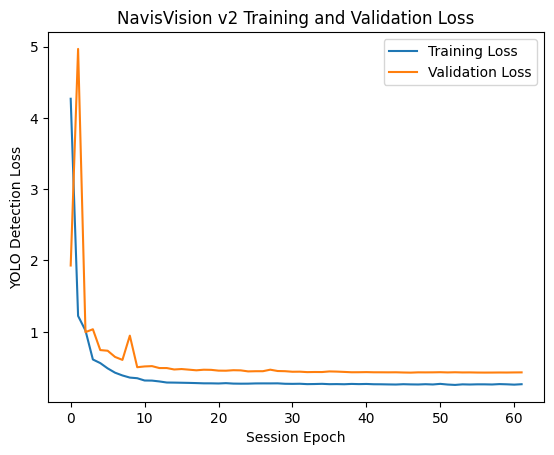

In [ ]:
# Keep False for the first traffic-control-only v2 run.
# Change to True only when continuing its compatible saved checkpoint.
RESUME_FROM_CHECKPOINT = False

model = NavisVision(
    num_classes=len(CLASS_NAMES),
    grid_size=16,
).to(device)
train_losses, val_losses = obj_train(
    model,
    batch_size=16,
    learning_rate=0.0005,
    num_epochs=100,
    image_size=416,
    checkpoint_path=NAVISVISION_CHECKPOINT,
    early_stopping_patience=15,
    resume_from_checkpoint=RESUME_FROM_CHECKPOINT,
)
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Session Epoch")
plt.ylabel("YOLO Detection Loss")
plt.title("NavisVision v2 Training and Validation Loss")
plt.legend()
plt.show()


# Evaluate Model

In [ ]:
# Evaluate the saved best NavisVision v2 checkpoint on the held-out test split.
from collections import defaultdict
from pathlib import Path
import numpy as np
import torch
import torchvision

EVAL_CHECKPOINT = NAVISVISION_CHECKPOINT
EVAL_CONFIDENCE_THRESHOLD = 0.50
EVAL_IOU_THRESHOLD = 0.50
EVAL_NMS_THRESHOLD = 0.40
EVAL_BATCH_SIZE = 16


def _cxcywh_to_xyxy(boxes):
    centers = boxes[..., :2]
    sizes = boxes[..., 2:].clamp_min(0.0)
    return torch.cat(
        (centers - sizes / 2, centers + sizes / 2), dim=-1
    ).clamp(0.0, 1.0)


def _decode_navisvision_batch(
    raw_predictions,
    score_floor=0.001,
    nms_threshold=EVAL_NMS_THRESHOLD,
):
    raw_predictions = raw_predictions.detach().float().cpu()
    _, grid_size, _, _ = raw_predictions.shape
    grid_y, grid_x = torch.meshgrid(
        torch.arange(grid_size),
        torch.arange(grid_size),
        indexing="ij",
    )
    grid_x = grid_x.float()
    grid_y = grid_y.float()
    decoded = []

    for image_predictions in raw_predictions:
        center_x = (image_predictions[..., 0].sigmoid() + grid_x) / grid_size
        center_y = (image_predictions[..., 1].sigmoid() + grid_y) / grid_size
        width = image_predictions[..., 2].sigmoid()
        height = image_predictions[..., 3].sigmoid()
        boxes = _cxcywh_to_xyxy(
            torch.stack((center_x, center_y, width, height), dim=-1)
        ).reshape(-1, 4)

        objectness = image_predictions[..., 4].sigmoid()
        class_probabilities = image_predictions[..., 5:].softmax(dim=-1)
        class_confidence, class_ids = class_probabilities.max(dim=-1)
        scores = (objectness * class_confidence).reshape(-1)
        class_ids = class_ids.reshape(-1)

        score_mask = scores >= score_floor
        boxes = boxes[score_mask]
        scores = scores[score_mask]
        class_ids = class_ids[score_mask]

        # Class-agnostic NMS prevents one physical object from receiving
        # several overlapping labels such as sign_30 and green_light.
        if len(boxes):
            kept = torchvision.ops.nms(boxes, scores, nms_threshold)
            decoded.append({
                "boxes": boxes[kept],
                "scores": scores[kept],
                "labels": class_ids[kept],
            })
        else:
            decoded.append({
                "boxes": torch.empty((0, 4)),
                "scores": torch.empty((0,)),
                "labels": torch.empty((0,), dtype=torch.long),
            })
    return decoded


def _match_class_predictions(
    predictions,
    ground_truth_by_image,
    iou_threshold,
    confidence_floor=0.0,
):
    predictions = sorted(
        (prediction for prediction in predictions if prediction[0] >= confidence_floor),
        key=lambda prediction: prediction[0],
        reverse=True,
    )
    matched = {
        image_id: torch.zeros(len(boxes), dtype=torch.bool)
        for image_id, boxes in ground_truth_by_image.items()
    }
    true_positives = []
    false_positives = []

    for score, image_id, predicted_box in predictions:
        ground_truth_boxes = ground_truth_by_image.get(image_id)
        if ground_truth_boxes is None or len(ground_truth_boxes) == 0:
            true_positives.append(0.0)
            false_positives.append(1.0)
            continue
        ious = torchvision.ops.box_iou(
            predicted_box.unsqueeze(0), ground_truth_boxes
        ).squeeze(0)
        best_iou, best_index = ious.max(dim=0)
        if best_iou.item() >= iou_threshold and not matched[image_id][best_index]:
            matched[image_id][best_index] = True
            true_positives.append(1.0)
            false_positives.append(0.0)
        else:
            true_positives.append(0.0)
            false_positives.append(1.0)

    total_ground_truth = sum(len(boxes) for boxes in ground_truth_by_image.values())
    return (
        torch.tensor(true_positives, dtype=torch.float32),
        torch.tensor(false_positives, dtype=torch.float32),
        total_ground_truth,
    )


def _average_precision(true_positives, false_positives, total_ground_truth):
    if total_ground_truth == 0:
        return float("nan")
    if len(true_positives) == 0:
        return 0.0
    cumulative_tp = true_positives.cumsum(0)
    cumulative_fp = false_positives.cumsum(0)
    recall = cumulative_tp / total_ground_truth
    precision = cumulative_tp / (cumulative_tp + cumulative_fp).clamp_min(1e-12)
    recall = torch.cat((torch.tensor([0.0]), recall, torch.tensor([1.0])))
    precision = torch.cat((torch.tensor([0.0]), precision, torch.tensor([0.0])))
    for index in range(len(precision) - 2, -1, -1):
        precision[index] = torch.maximum(precision[index], precision[index + 1])
    changes = (recall[1:] != recall[:-1]).nonzero(as_tuple=False).squeeze(1)
    return float(
        ((recall[changes + 1] - recall[changes]) * precision[changes + 1]).sum()
    )


def evaluate_navisvision_checkpoint(checkpoint_path=EVAL_CHECKPOINT):
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.is_file():
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

    try:
        payload = torch.load(
            checkpoint_path, map_location=device, weights_only=True
        )
    except TypeError:
        payload = torch.load(checkpoint_path, map_location=device)

    if int(payload.get("architecture_version", 1)) != NAVISVISION_ARCHITECTURE_VERSION:
        raise ValueError("This evaluation cell requires a NavisVision v2 checkpoint.")
    class_names = tuple(payload.get("classes", CLASS_NAMES))
    grid_size = int(payload.get("grid_size", 16))
    image_size = int(payload.get("image_size", 416))
    evaluation_model = NavisVision(
        num_classes=len(class_names),
        grid_size=grid_size,
    ).to(device)
    evaluation_model.load_state_dict(payload["model_state_dict"], strict=True)
    evaluation_model.eval()

    _, _, test_loader, _ = get_objdata_loader(
        batch_size=EVAL_BATCH_SIZE,
        image_size=image_size,
        num_workers=2,
    )
    predictions_by_class = defaultdict(list)
    ground_truth_by_class = defaultdict(dict)
    next_image_id = 0

    with torch.inference_mode():
        for images, target_list in test_loader:
            images = images.to(device, non_blocking=True)
            raw_predictions = evaluation_model(images)
            decoded_predictions = _decode_navisvision_batch(raw_predictions)
            for decoded, targets in zip(decoded_predictions, target_list):
                image_id = next_image_id
                next_image_id += 1
                targets = targets.detach().float().cpu()
                for class_id in range(len(class_names)):
                    class_targets = targets[targets[:, 0].long() == class_id]
                    if len(class_targets):
                        ground_truth_by_class[class_id][image_id] = _cxcywh_to_xyxy(
                            class_targets[:, 1:5]
                        )
                for box, score, class_id in zip(
                    decoded["boxes"], decoded["scores"], decoded["labels"]
                ):
                    predictions_by_class[int(class_id)].append(
                        (float(score), image_id, box)
                    )

    per_class_ap = {}
    per_class_counts = {}
    total_tp = total_fp = total_ground_truth = 0
    for class_id, class_name in enumerate(class_names):
        all_tp, all_fp, class_ground_truth = _match_class_predictions(
            predictions_by_class[class_id],
            ground_truth_by_class[class_id],
            EVAL_IOU_THRESHOLD,
            confidence_floor=0.0,
        )
        per_class_ap[class_name] = _average_precision(
            all_tp, all_fp, class_ground_truth
        )
        threshold_tp, threshold_fp, _ = _match_class_predictions(
            predictions_by_class[class_id],
            ground_truth_by_class[class_id],
            EVAL_IOU_THRESHOLD,
            confidence_floor=EVAL_CONFIDENCE_THRESHOLD,
        )
        class_tp = int(threshold_tp.sum().item())
        class_fp = int(threshold_fp.sum().item())
        class_fn = class_ground_truth - class_tp
        per_class_counts[class_name] = (class_tp, class_fp, class_fn)
        total_tp += class_tp
        total_fp += class_fp
        total_ground_truth += class_ground_truth

    total_fn = total_ground_truth - total_tp
    precision = total_tp / max(total_tp + total_fp, 1)
    recall = total_tp / max(total_tp + total_fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    valid_ap = [value for value in per_class_ap.values() if not np.isnan(value)]
    map_50 = float(np.mean(valid_ap)) if valid_ap else float("nan")

    print("NavisVision v2 best-checkpoint test performance")
    print("-" * 64)
    print(f"Checkpoint: {checkpoint_path}")
    print(f"Checkpoint epoch: {payload.get('epoch', 'unknown')}")
    print(f"Saved validation loss: {payload.get('validation_loss', 'unknown')}")
    print(f"Test images: {next_image_id:,}")
    print(f"Confidence / IoU / NMS: {EVAL_CONFIDENCE_THRESHOLD:.2f} / "
          f"{EVAL_IOU_THRESHOLD:.2f} / {EVAL_NMS_THRESHOLD:.2f}")
    print(f"mAP@0.50: {map_50:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 score: {f1:.4f}")
    print(f"TP={total_tp:,} | FP={total_fp:,} | FN={total_fn:,}")
    print()
    print("Per-class AP@0.50 and threshold counts")
    for class_name in class_names:
        average_precision = per_class_ap[class_name]
        displayed_ap = (
            f"{average_precision:.4f}" if not np.isnan(average_precision)
            else "N/A"
        )
        class_tp, class_fp, class_fn = per_class_counts[class_name]
        print(
            f"  {class_name:24s} AP={displayed_ap:>6s} | "
            f"TP={class_tp:3d} FP={class_fp:3d} FN={class_fn:3d}"
        )

    return {
        "map_50": map_50,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "true_positives": total_tp,
        "false_positives": total_fp,
        "false_negatives": total_fn,
        "per_class_ap_50": per_class_ap,
    }


navisvision_test_metrics = evaluate_navisvision_checkpoint()


Detection images: train=1120, validation=320, test=160
Training objects per class:
  traffic_light_green      206
  traffic_light_orange     98
  traffic_light_red        194
  traffic_sign_30          185
  traffic_sign_60          100
  traffic_sign_90          49
NavisVision v2 best-checkpoint test performance
----------------------------------------------------------------
Checkpoint: /content/drive/MyDrive/NavisAI/models/navisvision_v2_traffic_controls_best.pt
Checkpoint epoch: 47
Saved validation loss: 0.42770894765853884
Test images: 160
Confidence / IoU / NMS: 0.50 / 0.50 / 0.40
mAP@0.50: 0.6774
Precision: 0.9200
Recall: 0.4000
F1 score: 0.5576
TP=46 | FP=4 | FN=69

Per-class AP@0.50 and threshold counts
  traffic_light_green      AP=0.8281 | TP= 23 FP=  3 FN= 14
  traffic_light_orange     AP=0.6970 | TP=  5 FP=  0 FN=  6
  traffic_light_red        AP=0.4633 | TP=  7 FP=  1 FN= 22
  traffic_sign_30          AP=0.8508 | TP=  5 FP=  0 FN= 14
  traffic_sign_60          AP=0.6250 |

# **Transfer Detectors**



## Detection Data


In [ ]:
# Full-image dataset shared by the pretrained object detectors.
from pathlib import Path
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import functional as TF
from PIL import Image

DETECTION_IMAGE_SIZE = 416
DETECTION_BATCH_SIZE = 4
DETECTION_NUM_WORKERS = 2
DETECTION_SEED = 1000
PRETRAINED_DETECTOR_DIR = Path("/content/drive/MyDrive/NavisAI/models")
PRETRAINED_DETECTOR_DIR.mkdir(parents=True, exist_ok=True)

torch.manual_seed(DETECTION_SEED)
np.random.seed(DETECTION_SEED)
random.seed(DETECTION_SEED)


class PretrainedDetectionDataset(Dataset):
    """Convert the existing normalized YOLO labels into detector targets."""

    IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

    def __init__(self, image_dir, label_dir, image_size=416, training=False):
        self.image_dir = Path(image_dir)
        self.label_dir = Path(label_dir)
        self.image_size = int(image_size)
        self.training = bool(training)
        self.images = sorted(
            path for path in self.image_dir.iterdir()
            if path.suffix.lower() in self.IMAGE_EXTENSIONS
        )
        self.class_counts = torch.zeros(len(CLASS_NAMES), dtype=torch.long)

        if not self.images:
            raise FileNotFoundError(f"No images found in {self.image_dir}")

        for image_path in self.images:
            label_path = self.label_dir / f"{image_path.stem}.txt"
            if not label_path.exists():
                continue
            for line in label_path.read_text().splitlines():
                values = line.strip().split()
                if len(values) != 5:
                    continue
                original_id = int(float(values[0]))
                if original_id in ORIGINAL_CLASS_ID_TO_ACTIVE:
                    active_id = ORIGINAL_CLASS_ID_TO_ACTIVE[original_id]
                    self.class_counts[active_id] += 1

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image_path = self.images[index]
        label_path = self.label_dir / f"{image_path.stem}.txt"
        image = Image.open(image_path).convert("RGB")

        # Photometric augmentation does not invalidate the bounding boxes.
        # Horizontal flips are excluded because they mirror speed-limit digits.
        if self.training:
            image = TF.adjust_brightness(image, random.uniform(0.80, 1.20))
            image = TF.adjust_contrast(image, random.uniform(0.80, 1.20))
            image = TF.adjust_saturation(image, random.uniform(0.85, 1.15))
            if random.random() < 0.15:
                image = TF.gaussian_blur(image, kernel_size=3)

        image = TF.resize(image, [self.image_size, self.image_size])
        image_tensor = TF.to_tensor(image)

        boxes = []
        labels = []
        if label_path.exists():
            for line_number, line in enumerate(
                    label_path.read_text().splitlines(), start=1):
                values = line.strip().split()
                if not values:
                    continue
                if len(values) != 5:
                    raise ValueError(
                        f"{label_path}:{line_number} must contain "
                        "class_id center_x center_y width height"
                    )

                original_id, cx, cy, width, height = map(float, values)
                original_id = int(original_id)
                if original_id not in ORIGINAL_CLASS_ID_TO_ACTIVE:
                    continue
                if width <= 0.0 or height <= 0.0:
                    continue
                if not all(
                    0.0 <= value <= 1.0
                    for value in (cx, cy, width, height)
                ):
                    raise ValueError(f"Non-normalized YOLO box in {label_path}")

                left = max(0.0, (cx - width / 2.0) * self.image_size)
                top = max(0.0, (cy - height / 2.0) * self.image_size)
                right = min(
                    float(self.image_size),
                    (cx + width / 2.0) * self.image_size,
                )
                bottom = min(
                    float(self.image_size),
                    (cy + height / 2.0) * self.image_size,
                )
                if right <= left or bottom <= top:
                    continue

                boxes.append([left, top, right, bottom])
                # Torchvision reserves class 0 for the background.
                labels.append(ORIGINAL_CLASS_ID_TO_ACTIVE[original_id] + 1)

        boxes_tensor = (
            torch.tensor(boxes, dtype=torch.float32)
            if boxes else torch.empty((0, 4), dtype=torch.float32)
        )
        labels_tensor = (
            torch.tensor(labels, dtype=torch.int64)
            if labels else torch.empty((0,), dtype=torch.int64)
        )
        area = (
            (boxes_tensor[:, 2] - boxes_tensor[:, 0])
            * (boxes_tensor[:, 3] - boxes_tensor[:, 1])
        )

        target = {
            "boxes": boxes_tensor,
            "labels": labels_tensor,
            "image_id": torch.tensor([index], dtype=torch.int64),
            "area": area,
            "iscrowd": torch.zeros(len(labels_tensor), dtype=torch.int64),
        }
        return image_tensor, target


def detection_collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)


def _find_detection_split(root, candidates):
    for split_name in candidates:
        split_root = root / split_name
        image_dir = split_root / "images"
        label_dir = split_root / "labels"
        if image_dir.is_dir() and label_dir.is_dir():
            return image_dir, label_dir
    raise FileNotFoundError(
        f"Could not find images/ and labels/ for any of {candidates} under {root}"
    )


def get_pretrained_detection_loaders():
    root = Path(object_detection_data_path)
    train_dirs = _find_detection_split(root, ("train",))
    val_dirs = _find_detection_split(root, ("valid", "val", "validation"))
    try:
        test_dirs = _find_detection_split(root, ("test",))
    except FileNotFoundError:
        print("No test split found; using validation as the test split.")
        test_dirs = val_dirs

    train_dataset = PretrainedDetectionDataset(
        *train_dirs, image_size=DETECTION_IMAGE_SIZE, training=True
    )
    val_dataset = PretrainedDetectionDataset(
        *val_dirs, image_size=DETECTION_IMAGE_SIZE, training=False
    )
    test_dataset = PretrainedDetectionDataset(
        *test_dirs, image_size=DETECTION_IMAGE_SIZE, training=False
    )

    loader_options = dict(
        batch_size=DETECTION_BATCH_SIZE,
        num_workers=DETECTION_NUM_WORKERS,
        pin_memory=(device.type == "cuda"),
        collate_fn=detection_collate_fn,
    )
    if DETECTION_NUM_WORKERS > 0:
        loader_options.update(persistent_workers=True, prefetch_factor=2)

    train_loader = DataLoader(
        train_dataset, shuffle=True, **loader_options
    )
    val_loader = DataLoader(
        val_dataset, shuffle=False, **loader_options
    )
    test_loader = DataLoader(
        test_dataset, shuffle=False, **loader_options
    )

    print(
        f"Detection images: train={len(train_dataset):,}, "
        f"validation={len(val_dataset):,}, test={len(test_dataset):,}"
    )
    print("Training objects per class:")
    for class_name, count in zip(
            CLASS_NAMES, train_dataset.class_counts.tolist()):
        print(f"  {class_name:24s} {int(count):,}")

    return train_loader, val_loader, test_loader


(
    pretrained_train_loader,
    pretrained_val_loader,
    pretrained_test_loader,
) = get_pretrained_detection_loaders()


Detection images: train=1,120, validation=320, test=160
Training objects per class:
  traffic_light_green      206
  traffic_light_orange     98
  traffic_light_red        194
  traffic_sign_30          185
  traffic_sign_60          100
  traffic_sign_90          49


## Detection Tools

The shared utilities below compute AP per class, mAP@0.50, precision, recall, and F1 from complete detection outputs. Checkpoints are selected using validation mAP@0.50.

In [ ]:
# Shared mAP@0.50 and threshold metrics for every pretrained detector.
from collections import defaultdict
import time
import torchvision


def _average_precision(recall, precision):
    if recall.numel() == 0:
        return 0.0
    recall = torch.cat((torch.tensor([0.0]), recall, torch.tensor([1.0])))
    precision = torch.cat(
        (torch.tensor([0.0]), precision, torch.tensor([0.0]))
    )
    for index in range(precision.numel() - 2, -1, -1):
        precision[index] = torch.maximum(
            precision[index], precision[index + 1]
        )
    changed = torch.where(recall[1:] != recall[:-1])[0]
    return float(
        torch.sum(
            (recall[changed + 1] - recall[changed])
            * precision[changed + 1]
        )
    )


def calculate_detection_metrics(
    predictions,
    targets,
    iou_threshold=0.50,
    score_threshold=0.50,
):
    """Calculate class-wise AP and aggregate counts from detector outputs."""

    predictions_by_class = defaultdict(list)
    ground_truth_by_class = defaultdict(lambda: defaultdict(list))

    for image_index, (prediction, target) in enumerate(
            zip(predictions, targets)):
        for box, label in zip(target["boxes"], target["labels"]):
            ground_truth_by_class[int(label)][image_index].append(
                box.float()
            )

        for box, label, score in zip(
            prediction["boxes"],
            prediction["labels"],
            prediction["scores"],
        ):
            predictions_by_class[int(label)].append(
                (float(score), image_index, box.float())
            )

    per_class_ap = {}
    per_class_counts = {}
    total_tp = 0
    total_fp = 0
    total_fn = 0

    for class_id, class_name in enumerate(CLASS_NAMES, start=1):
        gt_for_class = ground_truth_by_class[class_id]
        gt_count = sum(len(boxes) for boxes in gt_for_class.values())
        ordered_predictions = sorted(
            predictions_by_class[class_id],
            key=lambda item: item[0],
            reverse=True,
        )

        matched_for_ap = defaultdict(set)
        true_positive = []
        false_positive = []

        for score, image_index, predicted_box in ordered_predictions:
            ground_truth_boxes = gt_for_class.get(image_index, [])
            if not ground_truth_boxes:
                true_positive.append(0.0)
                false_positive.append(1.0)
                continue

            gt_tensor = torch.stack(ground_truth_boxes)
            ious = torchvision.ops.box_iou(
                predicted_box.unsqueeze(0),
                gt_tensor,
            )[0]
            best_iou, best_position = ious.max(dim=0)
            best_position = int(best_position)

            if (
                float(best_iou) >= iou_threshold
                and best_position not in matched_for_ap[image_index]
            ):
                matched_for_ap[image_index].add(best_position)
                true_positive.append(1.0)
                false_positive.append(0.0)
            else:
                true_positive.append(0.0)
                false_positive.append(1.0)

        if gt_count > 0 and true_positive:
            tp_cumulative = torch.tensor(true_positive).cumsum(0)
            fp_cumulative = torch.tensor(false_positive).cumsum(0)
            recall = tp_cumulative / gt_count
            precision = tp_cumulative / (
                tp_cumulative + fp_cumulative
            ).clamp_min(1e-12)
            average_precision = _average_precision(recall, precision)
        elif gt_count > 0:
            average_precision = 0.0
        else:
            average_precision = float("nan")

        per_class_ap[class_name] = average_precision

        matched_for_counts = defaultdict(set)
        class_tp = 0
        class_fp = 0
        for score, image_index, predicted_box in ordered_predictions:
            if score < score_threshold:
                continue
            ground_truth_boxes = gt_for_class.get(image_index, [])
            if not ground_truth_boxes:
                class_fp += 1
                continue

            gt_tensor = torch.stack(ground_truth_boxes)
            ious = torchvision.ops.box_iou(
                predicted_box.unsqueeze(0),
                gt_tensor,
            )[0]
            best_iou, best_position = ious.max(dim=0)
            best_position = int(best_position)
            if (
                float(best_iou) >= iou_threshold
                and best_position not in matched_for_counts[image_index]
            ):
                matched_for_counts[image_index].add(best_position)
                class_tp += 1
            else:
                class_fp += 1

        class_fn = gt_count - class_tp
        per_class_counts[class_name] = (class_tp, class_fp, class_fn)
        total_tp += class_tp
        total_fp += class_fp
        total_fn += class_fn

    valid_ap = [
        value for value in per_class_ap.values()
        if not np.isnan(value)
    ]
    map_50 = float(np.mean(valid_ap)) if valid_ap else float("nan")
    precision = total_tp / max(total_tp + total_fp, 1)
    recall = total_tp / max(total_tp + total_fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)

    return {
        "map_50": map_50,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "true_positives": total_tp,
        "false_positives": total_fp,
        "false_negatives": total_fn,
        "per_class_ap_50": per_class_ap,
        "per_class_counts": per_class_counts,
        "score_threshold": score_threshold,
        "iou_threshold": iou_threshold,
    }


def evaluate_detector(predict_batch, loader):
    predictions = []
    targets = []
    for images, batch_targets in loader:
        batch_predictions = predict_batch(images)
        predictions.extend(
            {
                key: value.detach().float().cpu()
                if key in ("boxes", "scores")
                else value.detach().long().cpu()
                for key, value in prediction.items()
                if key in ("boxes", "labels", "scores")
            }
            for prediction in batch_predictions
        )
        targets.extend(
            {
                "boxes": target["boxes"].detach().float().cpu(),
                "labels": target["labels"].detach().long().cpu(),
            }
            for target in batch_targets
        )
    return calculate_detection_metrics(predictions, targets)


def print_detection_metrics(model_name, metrics, split_name="Test"):
    print(f"{model_name} {split_name.lower()} performance")
    print("-" * 70)
    print(f"mAP@0.50: {metrics['map_50']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"F1 score:  {metrics['f1']:.4f}")
    print(
        f"TP={metrics['true_positives']:,} | "
        f"FP={metrics['false_positives']:,} | "
        f"FN={metrics['false_negatives']:,}"
    )
    print()
    print("Per-class AP@0.50:")
    for class_name in CLASS_NAMES:
        average_precision = metrics["per_class_ap_50"][class_name]
        class_tp, class_fp, class_fn = (
            metrics["per_class_counts"][class_name]
        )
        print(
            f"  {class_name:24s} AP={average_precision:.4f} | "
            f"TP={class_tp:3d} FP={class_fp:3d} FN={class_fn:3d}"
        )


def plot_detector_history(history, model_name):
    epochs = history["epoch"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history["train_loss"], label="Training loss")
    axes[0].set_title(f"{model_name} training loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Detection loss")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].plot(
        epochs,
        history["val_map_50"],
        label="Validation mAP@0.50",
    )
    axes[1].set_title(f"{model_name} validation mAP")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("mAP@0.50")
    axes[1].set_ylim(0.0, 1.0)
    axes[1].grid(alpha=0.25)
    axes[1].legend()
    plt.tight_layout()
    plt.show()


## Train Faster R-CNN

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 194MB/s]
/tmp/ipykernel_495/3575568370.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)


Epoch 01 | loss 0.1330 | val mAP@0.50 0.5161 | 88.4s saved
Epoch 02 | loss 0.0827 | val mAP@0.50 0.7450 | 91.5s saved
Epoch 03 | loss 0.0669 | val mAP@0.50 0.7784 | 87.8s saved

Unfreezing the complete ResNet-50-FPN backbone.
Epoch 04 | loss 0.0576 | val mAP@0.50 0.8530 | 116.4s saved
Epoch 05 | loss 0.0447 | val mAP@0.50 0.8688 | 116.3s saved
Epoch 06 | loss 0.0362 | val mAP@0.50 0.9223 | 116.4s saved
Epoch 07 | loss 0.0316 | val mAP@0.50 0.9023 | 115.7s
Epoch 08 | loss 0.0282 | val mAP@0.50 0.9469 | 115.6s saved
Epoch 09 | loss 0.0301 | val mAP@0.50 0.8469 | 115.6s
Epoch 10 | loss 0.0304 | val mAP@0.50 0.9287 | 115.0s
Epoch 11 | loss 0.0245 | val mAP@0.50 0.9185 | 114.8s
Epoch 12 | loss 0.0176 | val mAP@0.50 0.9388 | 117.1s
Epoch 13 | loss 0.0150 | val mAP@0.50 0.9361 | 116.1s
Early stopping after 5 fine-tuning epochs without improvement.

Loaded best Faster R-CNN checkpoint from epoch 8 with validation mAP@0.50 0.9469.
Training time: 23.79 minutes
Checkpoint: /content/drive/MyDrive/

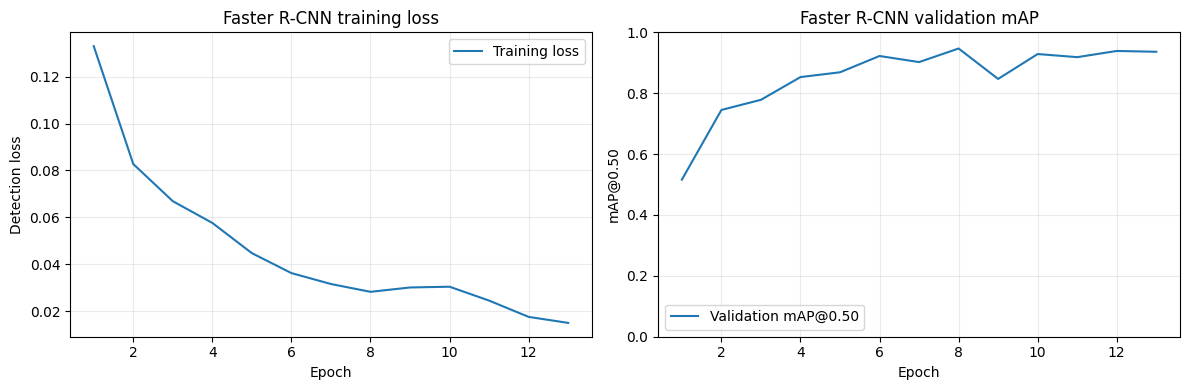

Faster R-CNN test performance
----------------------------------------------------------------------
mAP@0.50: 0.9768
Precision: 0.8871
Recall:    0.9565
F1 score:  0.9205
TP=110 | FP=14 | FN=5

Per-class AP@0.50:
  traffic_light_green      AP=0.9947 | TP= 36 FP=  3 FN=  1
  traffic_light_orange     AP=0.9675 | TP= 10 FP=  4 FN=  1
  traffic_light_red        AP=0.9512 | TP= 27 FP=  6 FN=  2
  traffic_sign_30          AP=0.9474 | TP= 18 FP=  1 FN=  1
  traffic_sign_60          AP=1.0000 | TP= 14 FP=  0 FN=  0
  traffic_sign_90          AP=1.0000 | TP=  5 FP=  0 FN=  0


In [ ]:
# Pretrained CNN object detector: Faster R-CNN with ResNet-50-FPN.
from torchvision.models.detection import (
    FasterRCNN_ResNet50_FPN_V2_Weights,
    fasterrcnn_resnet50_fpn_v2,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

FRCNN_EPOCHS = 20
FRCNN_HEAD_EPOCHS = 3
FRCNN_HEAD_LR = 5e-4
FRCNN_FINE_TUNE_LR = 1e-4
FRCNN_WEIGHT_DECAY = 1e-4
FRCNN_PATIENCE = 5
FRCNN_CHECKPOINT = (
    PRETRAINED_DETECTOR_DIR
    / "navisvision_fasterrcnn_resnet50_fpn_best.pt"
)


def build_fasterrcnn_detector():
    model = fasterrcnn_resnet50_fpn_v2(
        weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT,
        min_size=DETECTION_IMAGE_SIZE,
        max_size=DETECTION_IMAGE_SIZE,
    )
    input_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(
        input_features,
        len(CLASS_NAMES) + 1,
    )
    return model


def train_fasterrcnn():
    model = build_fasterrcnn_detector().to(device)
    amp_enabled = device.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)
    history = {"epoch": [], "train_loss": [], "val_map_50": []}
    best_map = -1.0
    stale_epochs = 0
    start_time = time.time()

    # First train only the new region-classification and box-regression heads.
    for parameter in model.backbone.parameters():
        parameter.requires_grad = False
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=FRCNN_HEAD_LR,
        weight_decay=FRCNN_WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
    )

    def predict_batch(images):
        model.eval()
        image_tensors = [
            image.to(device, non_blocking=True) for image in images
        ]
        with torch.inference_mode():
            return model(image_tensors)

    for epoch in range(1, FRCNN_EPOCHS + 1):
        if epoch == FRCNN_HEAD_EPOCHS + 1:
            print()
            print("Unfreezing the complete ResNet-50-FPN backbone.")
            for parameter in model.backbone.parameters():
                parameter.requires_grad = True
            optimizer = torch.optim.AdamW(
                model.parameters(),
                lr=FRCNN_FINE_TUNE_LR,
                weight_decay=FRCNN_WEIGHT_DECAY,
            )
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer,
                mode="max",
                factor=0.3,
                patience=2,
                min_lr=1e-7,
            )
            stale_epochs = 0

        model.train()
        total_loss = 0.0
        epoch_start = time.time()

        for images, targets in pretrained_train_loader:
            images = [
                image.to(device, non_blocking=True) for image in images
            ]
            targets = [
                {
                    key: value.to(device, non_blocking=True)
                    for key, value in target.items()
                }
                for target in targets
            ]

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=amp_enabled,
            ):
                loss_dictionary = model(images, targets)
                loss = sum(loss_dictionary.values())

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item() * len(images)

        train_loss = total_loss / len(pretrained_train_loader.dataset)
        validation_metrics = evaluate_detector(
            predict_batch,
            pretrained_val_loader,
        )
        validation_map = validation_metrics["map_50"]
        scheduler.step(validation_map)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_map_50"].append(validation_map)

        improved = validation_map > best_map + 1e-6
        if improved:
            best_map = validation_map
            stale_epochs = 0
            torch.save(
                {
                    "model_name": "Faster R-CNN ResNet-50-FPN",
                    "architecture": "fasterrcnn_resnet50_fpn_v2",
                    "task": "traffic_control_object_detection",
                    "pretrained": True,
                    "classes": tuple(CLASS_NAMES),
                    "image_size": DETECTION_IMAGE_SIZE,
                    "epoch": epoch,
                    "validation_map_50": best_map,
                    "model_state_dict": model.state_dict(),
                    "history": history,
                },
                FRCNN_CHECKPOINT,
            )
            saved_marker = " saved"
        else:
            stale_epochs += 1
            saved_marker = ""

        print(
            f"Epoch {epoch:02d} | loss {train_loss:.4f} | "
            f"val mAP@0.50 {validation_map:.4f} | "
            f"{time.time() - epoch_start:.1f}s{saved_marker}"
        )

        if (
            epoch > FRCNN_HEAD_EPOCHS
            and stale_epochs >= FRCNN_PATIENCE
        ):
            print(
                f"Early stopping after {FRCNN_PATIENCE} "
                "fine-tuning epochs without improvement."
            )
            break

    payload = torch.load(
        FRCNN_CHECKPOINT,
        map_location=device,
        weights_only=False,
    )
    model.load_state_dict(payload["model_state_dict"])
    model.eval()
    print()
    print(
        f"Loaded best Faster R-CNN checkpoint from epoch "
        f"{payload['epoch']} with validation mAP@0.50 "
        f"{payload['validation_map_50']:.4f}."
    )
    print(f"Training time: {(time.time() - start_time) / 60.0:.2f} minutes")
    print(f"Checkpoint: {FRCNN_CHECKPOINT}")

    plot_detector_history(history, "Faster R-CNN")
    test_metrics = evaluate_detector(
        predict_batch,
        pretrained_test_loader,
    )
    print_detection_metrics("Faster R-CNN", test_metrics)
    return {
        "model": model,
        "checkpoint": payload,
        "history": history,
        "test_metrics": test_metrics,
    }


fasterrcnn_results = train_fasterrcnn()


# Evaluate Model Detectors on New Data

In [ ]:
import torchvision

EVAL_CONFIDENCE_THRESHOLD = 0.50
EVAL_IOU_THRESHOLD = 0.50
EVAL_NMS_THRESHOLD = 0.40


def _cxcywh_to_xyxy(boxes):
    centers = boxes[..., :2]
    sizes = boxes[..., 2:].clamp_min(0.0)
    return torch.cat(
        (centers - sizes / 2, centers + sizes / 2), dim=-1
    ).clamp(0.0, 1.0)

def _decode_navisvision_batch(
    raw_predictions,
    score_floor=0.001,
    nms_threshold=EVAL_NMS_THRESHOLD,
):
    raw_predictions = raw_predictions.detach().float().cpu()
    _, grid_size, _, _ = raw_predictions.shape
    grid_y, grid_x = torch.meshgrid(
        torch.arange(grid_size),
        torch.arange(grid_size),
        indexing="ij",
    )
    grid_x = grid_x.float()
    grid_y = grid_y.float()
    decoded = []

    for image_predictions in raw_predictions:
        center_x = (
            image_predictions[..., 0].sigmoid() + grid_x
        ) / grid_size
        center_y = (
            image_predictions[..., 1].sigmoid() + grid_y
        ) / grid_size
        width = image_predictions[..., 2].sigmoid()
        height = image_predictions[..., 3].sigmoid()
        boxes = _cxcywh_to_xyxy(
            torch.stack((center_x, center_y, width, height), dim=-1)
        ).reshape(-1, 4)

        objectness = image_predictions[..., 4].sigmoid()
        class_probabilities = image_predictions[..., 5:].softmax(dim=-1)
        class_confidence, class_ids = class_probabilities.max(dim=-1)
        scores = (objectness * class_confidence).reshape(-1)
        class_ids = class_ids.reshape(-1)

        score_mask = scores >= score_floor
        boxes = boxes[score_mask]
        scores = scores[score_mask]
        class_ids = class_ids[score_mask]

        if len(boxes):
            kept = torchvision.ops.nms(boxes, scores, nms_threshold)
            decoded.append({
                "boxes": boxes[kept],
                "scores": scores[kept],
                "labels": class_ids[kept],
            })
        else:
            decoded.append({
                "boxes": torch.empty((0, 4)),
                "scores": torch.empty((0,)),
                "labels": torch.empty((0,), dtype=torch.long),
            })
    return decoded

def _match_class_predictions(
    predictions,
    ground_truth_by_image,
    iou_threshold,
    confidence_floor=0.0,
):
    predictions = sorted(
        (
            prediction for prediction in predictions
            if prediction[0] >= confidence_floor
        ),
        key=lambda prediction: prediction[0],
        reverse=True,
    )
    matched = {
        image_id: torch.zeros(len(boxes), dtype=torch.bool)
        for image_id, boxes in ground_truth_by_image.items()
    }
    true_positives = []
    false_positives = []

    for score, image_id, predicted_box in predictions:
        ground_truth_boxes = ground_truth_by_image.get(image_id)
        if ground_truth_boxes is None or len(ground_truth_boxes) == 0:
            true_positives.append(0.0)
            false_positives.append(1.0)
            continue

        ious = torchvision.ops.box_iou(
            predicted_box.unsqueeze(0), ground_truth_boxes
        ).squeeze(0)
        best_iou, best_index = ious.max(dim=0)
        if (
            best_iou.item() >= iou_threshold
            and not matched[image_id][best_index]
        ):
            matched[image_id][best_index] = True
            true_positives.append(1.0)
            false_positives.append(0.0)
        else:
            true_positives.append(0.0)
            false_positives.append(1.0)

    total_ground_truth = sum(
        len(boxes) for boxes in ground_truth_by_image.values()
    )
    return (
        torch.tensor(true_positives, dtype=torch.float32),
        torch.tensor(false_positives, dtype=torch.float32),
        total_ground_truth,
    )



In [ ]:
from pathlib import Path
from collections import defaultdict
from torch.utils.data import DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

NV_DATA_ROOT = Path("/content/drive/MyDrive/NavisAI/NV_new_data")
NV_BATCH_SIZE = 4

def _find_nv_data(root):
    for candidate in (root, root / "valid", root / "val", root / "validation"):
        image_dir = candidate / "images"
        label_dir = candidate / "labels"
        if image_dir.is_dir() and label_dir.is_dir():
            return image_dir, label_dir
    raise FileNotFoundError(
        f"Could not find images/ and labels/ under {root} or a valid/ subfolder."
    )

def _custom_collate(batch):
    images, targets = zip(*batch)
    return torch.stack(images), list(targets)

def _detector_collate(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)

def _ap_from_matches(true_positives, false_positives, ground_truth_count):
    if ground_truth_count == 0:
        return float("nan")
    if len(true_positives) == 0:
        return 0.0
    cumulative_tp = true_positives.cumsum(0)
    cumulative_fp = false_positives.cumsum(0)
    recall = cumulative_tp / ground_truth_count
    precision = cumulative_tp / (cumulative_tp + cumulative_fp).clamp_min(1e-12)
    recall = torch.cat((torch.tensor([0.0]), recall, torch.tensor([1.0])))
    precision = torch.cat((torch.tensor([0.0]), precision, torch.tensor([0.0])))
    for index in range(len(precision) - 2, -1, -1):
        precision[index] = torch.maximum(precision[index], precision[index + 1])
    changes = (recall[1:] != recall[:-1]).nonzero(as_tuple=False).squeeze(1)
    return float(
        ((recall[changes + 1] - recall[changes]) * precision[changes + 1]).sum()
    )

def _evaluate_custom_cnn(loader):
    checkpoint_path = Path(
        "/content/drive/MyDrive/NavisAI/models/"
        "navisvision_v2_traffic_controls_best.pt"
    )
    payload = torch.load(
        checkpoint_path, map_location=device, weights_only=False
    )
    class_names = tuple(payload.get("classes", CLASS_NAMES))
    model = NavisVision(
        num_classes=len(class_names),
        grid_size=int(payload.get("grid_size", 13)),
    ).to(device)
    model.load_state_dict(payload["model_state_dict"], strict=True)
    model.eval()

    predictions_by_class = defaultdict(list)
    ground_truth_by_class = defaultdict(dict)
    image_count = 0

    with torch.inference_mode():
        for images, target_list in loader:
            raw_predictions = model(images.to(device, non_blocking=True))
            decoded_predictions = _decode_navisvision_batch(raw_predictions)
            for decoded, targets in zip(decoded_predictions, target_list):
                image_id = image_count
                image_count += 1
                targets = targets.detach().float().cpu()
                for class_id in range(len(class_names)):
                    class_targets = targets[targets[:, 0].long() == class_id]
                    if len(class_targets):
                        ground_truth_by_class[class_id][image_id] = (
                            _cxcywh_to_xyxy(class_targets[:, 1:5])
                        )
                for box, score, class_id in zip(
                    decoded["boxes"], decoded["scores"], decoded["labels"]
                ):
                    predictions_by_class[int(class_id)].append(
                        (float(score), image_id, box)
                    )

    per_class_ap = {}
    per_class_counts = {}
    total_tp = total_fp = total_ground_truth = 0

    for class_id, class_name in enumerate(class_names):
        all_tp, all_fp, class_ground_truth = _match_class_predictions(
            predictions_by_class[class_id],
            ground_truth_by_class[class_id],
            EVAL_IOU_THRESHOLD,
            confidence_floor=0.0,
        )
        per_class_ap[class_name] = _ap_from_matches(
            all_tp, all_fp, class_ground_truth
        )
        threshold_tp, threshold_fp, _ = _match_class_predictions(
            predictions_by_class[class_id],
            ground_truth_by_class[class_id],
            EVAL_IOU_THRESHOLD,
            confidence_floor=EVAL_CONFIDENCE_THRESHOLD,
        )
        class_tp = int(threshold_tp.sum().item())
        class_fp = int(threshold_fp.sum().item())
        class_fn = class_ground_truth - class_tp
        per_class_counts[class_name] = (class_tp, class_fp, class_fn)
        total_tp += class_tp
        total_fp += class_fp
        total_ground_truth += class_ground_truth

    total_fn = total_ground_truth - total_tp
    precision = total_tp / max(total_tp + total_fp, 1)
    recall = total_tp / max(total_tp + total_fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    valid_ap = [value for value in per_class_ap.values() if not np.isnan(value)]

    return {
        "images": image_count,
        "map_50": float(np.mean(valid_ap)) if valid_ap else float("nan"),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "true_positives": total_tp,
        "false_positives": total_fp,
        "false_negatives": total_fn,
        "per_class_ap_50": per_class_ap,
        "per_class_counts": per_class_counts,
    }

def _evaluate_faster_rcnn(loader):
    checkpoint_path = Path(
        "/content/drive/MyDrive/NavisAI/models/"
        "navisvision_fasterrcnn_resnet50_fpn_best.pt"
    )
    payload = torch.load(
        checkpoint_path, map_location=device, weights_only=False
    )

    model = fasterrcnn_resnet50_fpn_v2(
        weights=None,
        weights_backbone=None,
        min_size=DETECTION_IMAGE_SIZE,
        max_size=DETECTION_IMAGE_SIZE,
    )
    input_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(
        input_features, len(CLASS_NAMES) + 1
    )
    model = model.to(device)
    model.load_state_dict(payload["model_state_dict"], strict=True)
    model.eval()

    predictions_by_class = defaultdict(list)
    ground_truth_by_class = defaultdict(dict)
    image_count = 0

    with torch.inference_mode():
        for images, batch_targets in loader:
            image_tensors = [
                image.to(device, non_blocking=True) for image in images
            ]
            batch_predictions = model(image_tensors)

            for prediction, target in zip(batch_predictions, batch_targets):
                image_id = image_count
                image_count += 1

                target_boxes = target["boxes"].detach().float().cpu()
                target_labels = target["labels"].detach().long().cpu()
                for class_id in range(1, len(CLASS_NAMES) + 1):
                    class_boxes = target_boxes[target_labels == class_id]
                    if len(class_boxes):
                        ground_truth_by_class[class_id][image_id] = class_boxes

                for box, score, class_id in zip(
                    prediction["boxes"].detach().float().cpu(),
                    prediction["scores"].detach().float().cpu(),
                    prediction["labels"].detach().long().cpu(),
                ):
                    predictions_by_class[int(class_id)].append(
                        (float(score), image_id, box)
                    )

    per_class_ap = {}
    per_class_counts = {}
    total_tp = total_fp = total_ground_truth = 0

    for class_id, class_name in enumerate(CLASS_NAMES, start=1):
        all_tp, all_fp, class_ground_truth = _match_class_predictions(
            predictions_by_class[class_id],
            ground_truth_by_class[class_id],
            EVAL_IOU_THRESHOLD,
            confidence_floor=0.0,
        )
        per_class_ap[class_name] = _ap_from_matches(
            all_tp, all_fp, class_ground_truth
        )

        threshold_tp, threshold_fp, _ = _match_class_predictions(
            predictions_by_class[class_id],
            ground_truth_by_class[class_id],
            EVAL_IOU_THRESHOLD,
            confidence_floor=EVAL_CONFIDENCE_THRESHOLD,
        )
        class_tp = int(threshold_tp.sum().item())
        class_fp = int(threshold_fp.sum().item())
        class_fn = class_ground_truth - class_tp
        per_class_counts[class_name] = (class_tp, class_fp, class_fn)
        total_tp += class_tp
        total_fp += class_fp
        total_ground_truth += class_ground_truth

    total_fn = total_ground_truth - total_tp
    precision = total_tp / max(total_tp + total_fp, 1)
    recall = total_tp / max(total_tp + total_fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    valid_ap = [
        value for value in per_class_ap.values()
        if not np.isnan(value)
    ]

    return {
        "images": image_count,
        "map_50": float(np.mean(valid_ap)) if valid_ap else float("nan"),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "true_positives": total_tp,
        "false_positives": total_fp,
        "false_negatives": total_fn,
        "per_class_ap_50": per_class_ap,
        "per_class_counts": per_class_counts,
    }

def _print_metrics(model_name, metrics):
    print(model_name)
    print("-" * 64)
    print(f"Images: {metrics['images']:,}")
    print(f"mAP@0.50: {metrics['map_50']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 score: {metrics['f1']:.4f}")
    print(
        f"TP={metrics['true_positives']:,} | "
        f"FP={metrics['false_positives']:,} | "
        f"FN={metrics['false_negatives']:,}"
    )
    print()
    for class_name in CLASS_NAMES:
        average_precision = metrics["per_class_ap_50"][class_name]
        displayed_ap = (
            f"{average_precision:.4f}" if not np.isnan(average_precision)
            else "N/A"
        )
        class_tp, class_fp, class_fn = metrics["per_class_counts"][class_name]
        print(
            f"{class_name:24s} AP={displayed_ap:>6s} | "
            f"TP={class_tp:3d} FP={class_fp:3d} FN={class_fn:3d}"
        )
    print()

nv_image_dir, nv_label_dir = _find_nv_data(NV_DATA_ROOT)

custom_dataset = YoloDetectionDataset(
    nv_image_dir, nv_label_dir, image_size=416, training=False
)
custom_loader = DataLoader(
    custom_dataset,
    batch_size=NV_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda"),
    collate_fn=_custom_collate,
)

faster_dataset = PretrainedDetectionDataset(
    nv_image_dir, nv_label_dir, image_size=DETECTION_IMAGE_SIZE, training=False
)
faster_loader = DataLoader(
    faster_dataset,
    batch_size=NV_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda"),
    collate_fn=_detector_collate,
)

custom_cnn_metrics = _evaluate_custom_cnn(custom_loader)
faster_rcnn_metrics = _evaluate_faster_rcnn(faster_loader)

_print_metrics("Custom CNN", custom_cnn_metrics)
_print_metrics("Faster R-CNN", faster_rcnn_metrics)


Custom CNN
----------------------------------------------------------------
Images: 320
mAP@0.50: 0.7486
Precision: 0.9250
Recall: 0.4606
F1 score: 0.6150
TP=111 | FP=9 | FN=130

traffic_light_green      AP=0.8275 | TP= 44 FP=  3 FN= 15
traffic_light_orange     AP=0.7507 | TP= 13 FP=  1 FN= 11
traffic_light_red        AP=0.5545 | TP= 14 FP=  2 FN= 49
traffic_sign_30          AP=0.8999 | TP= 22 FP=  0 FN= 28
traffic_sign_60          AP=0.6952 | TP= 14 FP=  3 FN= 22
traffic_sign_90          AP=0.7639 | TP=  4 FP=  0 FN=  5

Faster R-CNN
----------------------------------------------------------------
Images: 320
mAP@0.50: 0.9469
Precision: 0.8636
Recall: 0.9461
F1 score: 0.9030
TP=228 | FP=36 | FN=13

traffic_light_green      AP=0.9583 | TP= 56 FP=  6 FN=  3
traffic_light_orange     AP=1.0000 | TP= 24 FP=  1 FN=  0
traffic_light_red        AP=0.9143 | TP= 58 FP= 22 FN=  5
traffic_sign_30          AP=0.9778 | TP= 48 FP=  3 FN=  2
traffic_sign_60          AP=0.9543 | TP= 35 FP=  4 FN=  1
t